In [ ]:
# Nếu cần, cài đặt repvgg (nếu chưa có sẵn)
!pip install timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import torch
import torch.nn as nn
import timm

# Thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tạo mô hình RepVGG
model = timm.create_model('repvgg_b0', pretrained=True, num_classes=2)  # Binary classification
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/63.5M [00:00<?, ?B/s]

In [ ]:
from google.colab import files
files.upload()  # Tải lên kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"orangecamtus","key":"20d96d48efb95c1088fa7473ae6fc079"}'}

In [ ]:
# Tạo thư mục Kaggle và di chuyển file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
# Tải 3 bộ dữ liệu
!kaggle datasets download -d lfreedom2750/fakeface-train-data-v2
!kaggle datasets download -d lfreedom2750/fakeface-valid-data-v2
!kaggle datasets download -d lfreedom2750/fakeface-test-data-v2

# Giải nén
!unzip -q fakeface-train-data-v2.zip -d train
!unzip -q fakeface-valid-data-v2.zip -d valid
!unzip -q fakeface-test-data-v2.zip -d test


Dataset URL: https://www.kaggle.com/datasets/lfreedom2750/fakeface-train-data-v2
License(s): unknown
 99% 2.18G/2.21G [00:11<00:00, 269MB/s]
100% 2.21G/2.21G [00:11<00:00, 207MB/s]
Dataset URL: https://www.kaggle.com/datasets/lfreedom2750/fakeface-valid-data-v2
License(s): unknown
 96% 718M/745M [00:11<00:00, 74.4MB/s]
100% 745M/745M [00:12<00:00, 64.7MB/s]
Dataset URL: https://www.kaggle.com/datasets/lfreedom2750/fakeface-test-data-v2
License(s): unknown
 99% 741M/747M [00:20<00:00, 88.4MB/s]
100% 747M/747M [00:20<00:00, 38.5MB/s]
unzip:  cannot find or open fakeface-train-data.zip, fakeface-train-data.zip.zip or fakeface-train-data.zip.ZIP.
unzip:  cannot find or open fakeface-valid-data.zip, fakeface-valid-data.zip.zip or fakeface-valid-data.zip.ZIP.
unzip:  cannot find or open fakeface-test-data.zip, fakeface-test-data.zip.zip or fakeface-test-data.zip.ZIP.


In [ ]:
!unzip -q fakeface-train-data-v2.zip -d train
!unzip -q fakeface-valid-data-v2.zip -d valid
!unzip -q fakeface-test-data-v2.zip -d test

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from tqdm import tqdm
import logging



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Đường dẫn dataset
train_dir = "test"
val_dir = "valid"
test_dir = "test"

# Tiền xử lý ảnh
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)





Using device: cuda


In [ ]:
import time
from sklearn.metrics import classification_report
from tqdm import tqdm
import logging

# Logging
logging.basicConfig(filename='train.log', level=logging.INFO)

# Loss, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
best_val_acc = 0
epochs = 5
total_train_time = 0

for epoch in range(epochs):
    epoch_start = time.time()

    model.train()
    train_loss, train_correct = 0.0, 0

    for inputs, labels in tqdm(train_loader, desc=f"[Epoch {epoch+1}] Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_dataset)
    train_acc = train_correct / len(train_dataset)

    # Validation
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_dataset)
    val_acc = val_correct / len(val_dataset)

    epoch_time = time.time() - epoch_start
    total_train_time += epoch_time

    # Logging
    log_msg = (f"Epoch {epoch+1}/{epochs} | "
               f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
               f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
               f"Time: {epoch_time:.2f}s")
    print(log_msg)
    logging.info(log_msg)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "model_best.pth")
        print("✅ Saved best model (based on validation accuracy)")

print(f"\n🕒 Total Training Time: {total_train_time:.2f} seconds")

# Load best model
model.load_state_dict(torch.load("model_best.pth"))

# Testing
model.eval()
y_true, y_pred = [], []
test_start = time.time()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
test_time = time.time() - test_start

# Report
print("\n🎯 Classification Report on Test Set:")
report = classification_report(y_true, y_pred, target_names=test_dataset.classes, digits=4)
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

print(f"\n🧪 Testing Time: {test_time:.2f} seconds")


[Epoch 1] Training: 100%|██████████| 625/625 [05:26<00:00,  1.91it/s]


Epoch 1/5 | Train Loss: 0.1550 Acc: 0.9348 | Val Loss: 0.1468 Acc: 0.9460 | Time: 466.58s
✅ Saved best model (based on validation accuracy)


[Epoch 2] Training: 100%|██████████| 625/625 [05:11<00:00,  2.00it/s]


Epoch 2/5 | Train Loss: 0.0222 Acc: 0.9922 | Val Loss: 0.2199 Acc: 0.9312 | Time: 454.35s


[Epoch 3] Training: 100%|██████████| 625/625 [05:12<00:00,  2.00it/s]


...

Epoch 4/5 | Train Loss: 0.0155 Acc: 0.9945 | Val Loss: 0.1711 Acc: 0.9475 | Time: 455.55s


[Epoch 5] Training: 100%|██████████| 625/625 [05:11<00:00,  2.00it/s]


Epoch 5/5 | Train Loss: 0.0119 Acc: 0.9955 | Val Loss: 0.2488 Acc: 0.9329 | Time: 453.92s

🕒 Total Training Time: 2285.19 seconds


Testing: 100%|██████████| 625/625 [02:23<00:00,  4.36it/s]


🎯 Classification Report on Test Set:
              precision    recall  f1-score   support

        fake     0.9980    0.9961    0.9971     20000
        real     0.9962    0.9980    0.9971     20000

    accuracy                         0.9971     40000
   macro avg     0.9971    0.9971    0.9971     40000
weighted avg     0.9971    0.9971    0.9971     40000


🧪 Testing Time: 143.30 seconds


In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving 5f073e42-80cb-4d20-8af0-dcb44f7f6822.jpg to 5f073e42-80cb-4d20-8af0-dcb44f7f6822.jpg
Saving 35ca6fb0-8279-45d3-bf7f-8b4ef12ada54.jpg to 35ca6fb0-8279-45d3-bf7f-8b4ef12ada54.jpg
Saving 057e92d4-eeb8-48dc-9ab9-caee53582ad9.jpg to 057e92d4-eeb8-48dc-9ab9-caee53582ad9.jpg
Saving 536e19f1-a7ff-4cf2-9306-be4e228efeaa.jpg to 536e19f1-a7ff-4cf2-9306-be4e228efeaa.jpg
Saving 957de5d4-e257-4adc-91e5-4e79654eaf54.jpg to 957de5d4-e257-4adc-91e5-4e79654eaf54.jpg
Saving b782507a-93e0-48e3-9b4a-35068302485b.jpg to b782507a-93e0-48e3-9b4a-35068302485b.jpg


In [ ]:
import os
os.listdir('/content')


['.config',
 '5f073e42-80cb-4d20-8af0-dcb44f7f6822.jpg',
 'kaggle.json',
 'drive',
 '536e19f1-a7ff-4cf2-9306-be4e228efeaa.jpg',
 'test',
 'fakeface-train-data-v2.zip',
 '957de5d4-e257-4adc-91e5-4e79654eaf54.jpg',
 'fakeface-valid-data-v2.zip',
 'classification_report.txt',
 'b782507a-93e0-48e3-9b4a-35068302485b.jpg',
 'valid',
 'fakeface-test-data-v2.zip',
 '057e92d4-eeb8-48dc-9ab9-caee53582ad9.jpg',
 '35ca6fb0-8279-45d3-bf7f-8b4ef12ada54.jpg',
 'train',
 'model_best.pth',
 'sample_data']

In [ ]:
import torch
import timm

# Load kiến trúc RepVGG-B0 (không dùng pretrained vì sẽ load trọng số riêng)
model = timm.create_model('repvgg_b0', pretrained=False, num_classes=2)

# Load trọng số đã huấn luyện
model.load_state_dict(torch.load("/content/model_best.pth", map_location=torch.device('cpu')))

# Đưa model về chế độ đánh giá
model.eval()


ByobNet(
  (stem): RepVggBlock(
    (conv_kxk): ConvNormAct(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (conv_1x1): ConvNormAct(
      (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (bn): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (drop_path): Identity()
    (attn): Identity()
    (act): ReLU(inplace=True)
  )
  (stages): Sequential(
    (0): Sequential(
      (0): RepVggBlock(
        (conv_kxk): ConvNormAct(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          

In [ ]:
from google.colab import files

uploaded = files.upload()


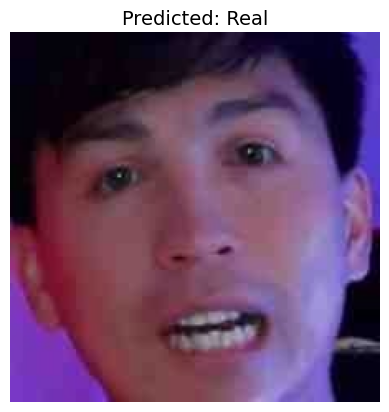

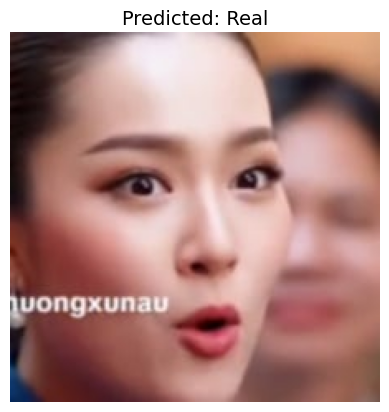

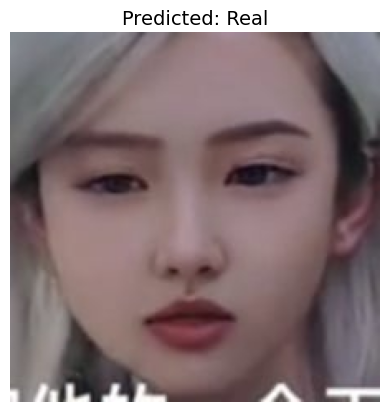

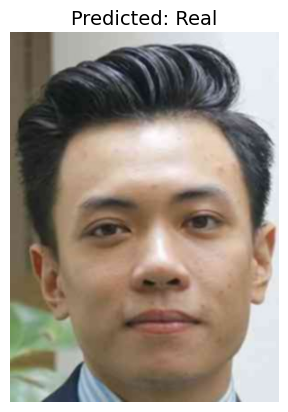

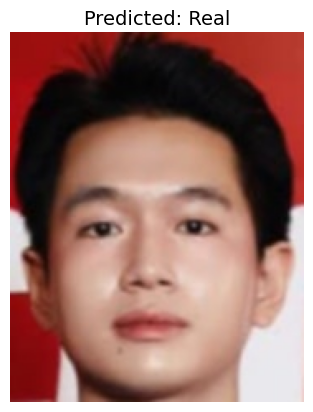

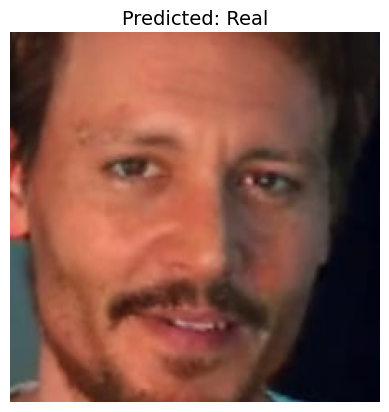

In [ ]:
# Bước 4: Dự đoán ảnh
import matplotlib.pyplot as plt
from PIL import Image
# Lặp qua các file ảnh đã upload (bỏ qua .pth)
for filename in uploaded:
    if filename.endswith('.jpg') or filename.endswith('.png'):
        # Load và hiển thị ảnh
        img = Image.open(filename).convert("RGB")
        plt.imshow(img)
        plt.axis("off")

        # Tiền xử lý
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        input_tensor = transform(img).unsqueeze(0)

        # Dự đoán
        with torch.no_grad():
            output = model(input_tensor)
            predicted = torch.argmax(output, 1)

        # Tên lớp (thay bằng label thật nếu có)
        class_names = ['Fake', 'Real']
        predicted_label = class_names[predicted.item()]

        # In kết quả dưới ảnh
        plt.title(f"Predicted: {predicted_label}", fontsize=14)
        plt.show()
